In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
import astropy.coordinates as coord

In [3]:
GalCoords = pd.read_csv('Resources/AstroHW2Coordinates.csv')
GalCoords

,Name,GalacticLongitude,GalacticLatitude,Distance(kpc)
0,M107,3.37,23.01,6.4
1,Terzan9,3.60,-1.99,6.5
2,UKS 1,5.12,0.76,8.3
3,M22,9.89,-7.55,3.2
4,IC1257,16.53,15.14,25.0
5,M2,53.38,-35.78,11.5
6,M71,56.74,-4.56,4.0
7,Lynga 7,328.77,-2.79,7.2
8,NGC 5053,335.69,78.94,16.4
9,Pismis 26,350.80,-3.42,8.1


In [4]:
# Galactic Coordinate Stuff
def hourangleconvert(hms):
    """
    Takes a 3-Tuple of shape (hours,minutes,seconds) and converts it into an astropy hourangle value.
    """
    hours,minutes,seconds = hms
    return (hours + minutes/60 + seconds/3600) * u.hourangle

def degreeconvert(degrees):
    """
    Takes a 3-Tuple of shape (degrees,arcminutes,arcseconds) and converts it into an astropy degree value.
    """
    deg,arcmin,arcsec = degrees
    return (deg + (arcmin/60)+(arcsec/3600)) * u.deg

def hour_to_deg(hour):
    """
    Takes an astropy hour angle value and converts it into degrees.
    """
    return hour * 15 / u.hourangle * u.deg
a_NGP = (12,51,26.28)
d_NGP = (27,7,41.7)

degreeconvert(d_NGP)

a_GalOrigin = (17,45,37.20)
d_GalOrigin = (-28,56,9.6)

l_NCP = (122,55,55.2)
b_NCP = (27,7,41.7)

# Intersection of the celestial equator with the Galactic equator moving eastward
# from negative to positive declination (ascending node)
a_ascending = (18,51,24)
d_ascending = (0,0,0)

l_ascending = (33,0,0)
b_ascending = (0,0,0)




In [5]:
# Converting Equatorial to Galactic (a,d) to (l,b)
np.sin(b)=np.sin(d_NGP)*np.sin(d)+np.cos(d_NGP)*np.cos(d)*np.cos(a-a_NGP)
np.cos(b)*np.sin(l_NCP-l)=np.cos(d)*np.sin(a-a_NGP)
np.cos(b)*np.cos(l_NCP-l)=np.cos(d_NGP)*np.sin(d)-np.sin(d_NGP)*np.cos(d)*np.cos(a-a_NGP)

# Converting Galactic to Equatorial (l,b) to (a,d)
np.sin(d)=np.sin(d_NGP)*np.sin(b)+np.cos(d_NGP)*np.cos(b)*np.cos(l_NCP-l)
np.cos(d)*np.sin(a-a_NGP)=np.cos(b)*np.sin(l_NCP-l)
np.cos(d)*np.cos(a-a_NGP)=np.cos(d_NGP)*np.sin(b)-np.sin(d_NGP)*np.cos(b)*np.cos(l_NCP-l)

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (1280089962.py, line 2)

In [26]:
def latlong_to_xy(lat,long,distance):
    R = distance
    x = R * np.cos(lat) *np.cos(long)
    y = R * np.cos(lat) * np.sin(long)
    z = R * np.sin(lat)
    return x,y,z

long = np.radians(GalCoords['GalacticLongitude'][0])
lat = np.radians(GalCoords['GalacticLatitude'][0])
distance = GalCoords['Distance(kpc)'][0]

latlong_to_xy(lat,long,distance)
cartesian=[0,0,0]
for name in GalCoords['Name']:
    cluster = GalCoords[GalCoords['Name']==name].reset_index(drop=True)
    lat,long,distance = cluster['GalacticLatitude'],cluster['GalacticLongitude'],cluster['Distance(kpc)']
    x,y,z = latlong_to_xy(np.radians(lat),np.radians(long),distance)
    x=x.squeeze()
    y=y.squeeze()
    tempstack = [name,x,y]
    cartesian = np.vstack((cartesian,tempstack))

6.625874950750035 3.3266234559711547 2.2237723356894907


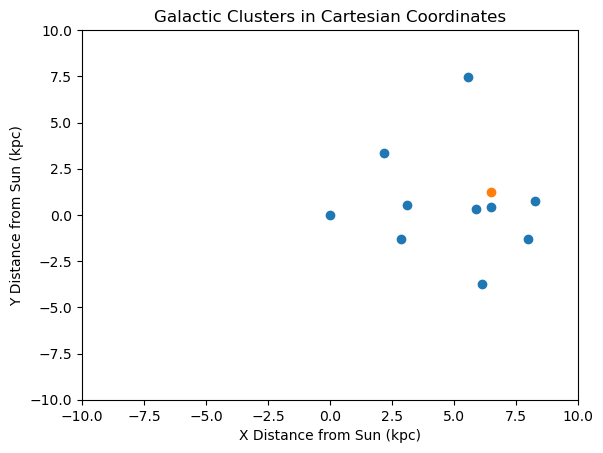

In [59]:
x_plotting,y_plotting = cartesian[:,1].astype(float),cartesian[:,2].astype(float)
plt.scatter(x_plotting,y_plotting)

plt.xlim(-10,10)
plt.ylim(-10,10)

x_mean = np.mean(x_plotting)
y_mean = np.mean(y_plotting)

plt.scatter(x_mean,y_mean)

distance_to_center = np.sqrt(x_mean**2+y_mean**2)
distance_to_center

sigma_x = 0
sigma_y = 0

for i in range(0,len(x_plotting)-1):
    sigma_x += np.sqrt((x_plotting[i]-x_mean)**2 /len(x_plotting))
    sigma_y += np.sqrt((y_plotting[i]-y_mean)**2 /len(y_plotting))


sigma_xbar = 1/np.sqrt(len(x_plotting)+1) * sigma_x
sigma_ybar = 1/np.sqrt(len(y_plotting)+1) * sigma_y
plt.title('Galactic Clusters in Cartesian Coordinates')
plt.xlabel('X Distance from Sun (kpc)')
plt.ylabel('Y Distance from Sun (kpc)')

print(distance_to_center,sigma_xbar,sigma_ybar)

Text(0, 0.5, 'Y Distance from Sun (kpc)')

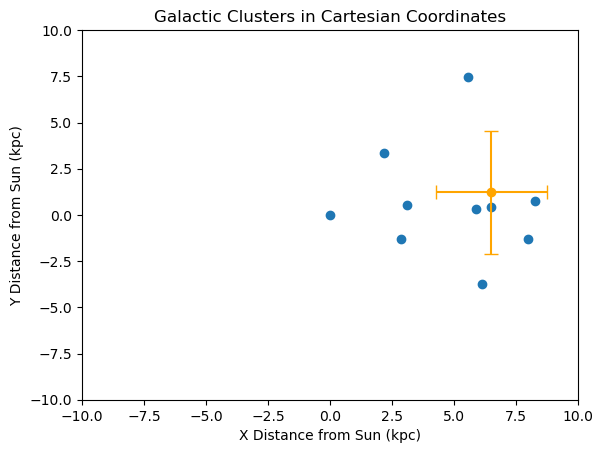

In [12]:
plt.scatter(x_plotting,y_plotting)
#plt.errorbar(x_plotting,y_plotting,sigma_x,sigma_y, fmt='o',capsize=5)
plt.errorbar(x_mean,y_mean,sigma_xbar,sigma_ybar,fmt='o',capsize=5,c='orange')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.title('Galactic Clusters in Cartesian Coordinates')
plt.xlabel('X Distance from Sun (kpc)')
plt.ylabel('Y Distance from Sun (kpc)')

Text(0.5, 1.0, 'Thin Disk Luminosity Density vs Height from Galactic Plane')

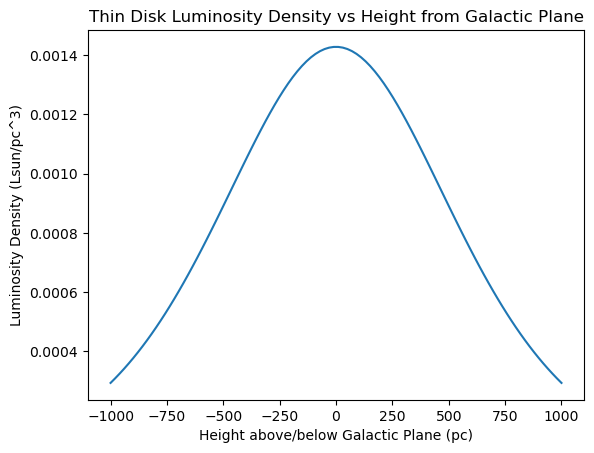

In [54]:
# Thin disk luminosity
zthin = 350 * u.pc
thindiskluminosity = lambda z: 0.05 * u.L_sun/(u.pc**3)*np.exp((-8 * u.kpc)/(2.25 * u.kpc)) * (2/(np.exp(z/(2*zthin))+np.exp(-z/(2*zthin))))**2
z = np.linspace(-1000,1000,100) * u.pc
plt.plot(z,thindiskluminosity(z))
plt.xlabel('Height above/below Galactic Plane (pc)')
plt.ylabel('Luminosity Density (Lsun/pc^3)')
plt.title('Thin Disk Luminosity Density vs Height from Galactic Plane')

# plt.title(f'Luminosity Density When z >> z$_0$')
# proofluminosity = lambda z: 4 * 0.05 * u.L_sun/(u.pc**3)*np.exp((-8 * u.kpc)/(2.25 * u.kpc)) * np.exp(-2*z/(2*zthin))
# plt.plot(proofluminosity(z),z)

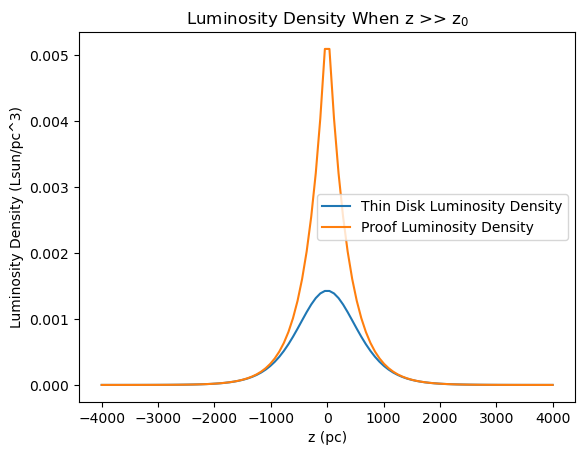

In [55]:
z = np.linspace(-4000,4000,100) * u.pc
plt.xlabel('z (pc)')
plt.ylabel('Luminosity Density (Lsun/pc^3)')
plt.title('Thin Disk Luminosity Density vs Height from Galactic Plane')

plt.title(f'Luminosity Density When z >> z$_0$')
plt.plot(z,thindiskluminosity(z),label='Thin Disk Luminosity Density')
proofluminosity = lambda z: 4 * 0.05 * u.L_sun/(u.pc**3)*np.exp((-8 * u.kpc)/(2.25 * u.kpc)) * np.exp(-np.abs(2*z/(2*zthin)))
plt.plot(z,proofluminosity(z),label='Proof Luminosity Density')
plt.legend()
#plt.yscale('log')

In [ ]:
# Estimate the heigh above and below the galactic plane for M13 ( l = 59.0 deg, b = 40.9 deg, d = 7.0 kpc) and the Orion Nebula
# (l = 209 deg, b = -19.4, d = 450 pc) respectively.
m13_l = 59.0 * u.deg
m13_b = 40.9 * u.deg
m13_d = 7.0 * u.kpc

m13_z = m13_d * np.sin(np.radians(m13_b))
print(m13_z)

orion_l = 209.0 * u.deg
orion_b = -19.4 * u.deg
orion_d = 450 * u.pc
orion_z = orion_d * np.sin(np.radians(orion_b))
print(orion_z)


4.583185696021378 kpc
-149.4725093476665 pc
